# Fashion-MNIST 分类（ResNet 小型示例）

本 Notebook 基于项目目录下的代码，将训练、评估、可视化和结果保存的过程按教学要求整理为 Markdown 说明与可执行代码单元。

说明：如果需要运行完整训练，请在具有 GPU/足够计算资源的环境中执行训练单元（或将 `EPOCHS` 降低以便快速演示）。

## 项目思路与 ResNet 选择理由

- Fashion-MNIST 是一个典型的图像分类任务，图像分辨率较低但类别较多，适合用卷积神经网络提取局部特征。
- ResNet 通过“残差连接”（skip connection）解决了深度网络训练时梯度消失和退化问题，使模型在保持可训练性的同时能够学习更深层次的特征。
- 本项目选择 ResNet 小型示例，原因包括：
  - 保持网络结构简洁，便于在有限计算资源下快速训练和演示；
  - 利用残差块提升模型稳定性，避免传统深度网络训练不收敛；
  - ResNet 对图像分类任务表现良好，可以作为 Fashion-MNIST 分类的有效基线模型。
- 该 Notebook 还保留项目原有的训练、评估和结果保存流程，以便对比实验与复现分析。

## 1. 环境与依赖

首先导入必要库，并检查 `config` 与 `utils` 是否可用。

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time

import config
from utils import load_fashion_mnist, plot_sample_images, plot_training_history, plot_confusion_matrix, print_classification_report, save_training_history_to_excel

print('config.OUTPUT_DIR =', config.OUTPUT_DIR)
print('NUM_CLASSES =', config.NUM_CLASSES)


config.OUTPUT_DIR = /output
NUM_CLASSES = 10


## 2. 数据加载与预处理

载入 Fashion-MNIST（项目 `data/` 目录下的 idx 文件），并构造训练/验证/测试集划分。

In [2]:
(train_images, train_labels), (test_images, test_labels) = load_fashion_mnist(config.DATA_DIR)
print('train_images.shape =', train_images.shape)
print('train_labels.shape =', train_labels.shape)
print('test_images.shape =', test_images.shape)
print('test_labels.shape =', test_labels.shape)

# 将数据合并并划分训练/验证/测试（与项目一致）
from sklearn.model_selection import train_test_split
X_all = np.concatenate([train_images, test_images], axis=0)
y_all = np.concatenate([train_labels, test_labels], axis=0)
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.30, random_state=config.RANDOM_SEED, stratify=y_all)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=config.RANDOM_SEED, stratify=y_temp)

X_train = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_val = X_val.reshape(-1, 28, 28, 1).astype('float32')
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32')

print('X_train.shape =', X_train.shape)
print('X_val.shape =', X_val.shape)
print('X_test.shape =', X_test.shape)

train_images.shape = (60000, 28, 28)
train_labels.shape = (60000,)
test_images.shape = (10000, 28, 28)
test_labels.shape = (10000,)
X_train.shape = (49000, 28, 28, 1)
X_val.shape = (10500, 28, 28, 1)
X_test.shape = (10500, 28, 28, 1)


## 3. 模型定义（ResNet 小型示例）

下面定义与项目相同的 `create_resnet_model()` 函数，可直接复用项目训练流程。

In [3]:
def residual_block(inputs, filters, stride=1):
    x = Conv2D(filters, (3, 3), strides=stride, padding='same', kernel_initializer='he_normal')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, (3, 3), strides=1, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)

    shortcut = inputs
    if stride != 1 or inputs.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), strides=stride, padding='same', kernel_initializer='he_normal')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

def create_resnet_model():
    inputs = Input(shape=(28, 28, 1))
    x = Conv2D(32, (3, 3), strides=1, padding='same', kernel_initializer='he_normal')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = residual_block(x, 32, stride=1)
    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64, stride=1)

    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(config.NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='ResNet_Small')
    return model

model = create_resnet_model()
model.summary()



Model: "ResNet_Small"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 28, 28, 1)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 28, 28, 32)           320       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 28, 28, 32)           128       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 28, 28, 32)           0         ['batch_normaliza

## 4. 训练

下面的单元展示训练流程。为演示可以把 `epochs` 设为较小值（例如 3）。

In [4]:
# 示例：仅作快速演示，实际训练请根据需要设置更大的 epochs/批次大小
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=3, batch_size=64, callbacks=[early_stop])
print('训练完成')


Epoch 1/3


766/766 [==============================] - 26s 32ms/step - loss: 0.6832 - accuracy: 0.7600 - val_loss: 0.4930 - val_accuracy: 0.8196
Epoch 2/3
766/766 [==============================] - 25s 32ms/step - loss: 0.3995 - accuracy: 0.8592 - val_loss: 0.4039 - val_accuracy: 0.8571
Epoch 3/3
766/766 [==============================] - 26s 33ms/step - loss: 0.3328 - accuracy: 0.8837 - val_loss: 0.3432 - val_accuracy: 0.8793
训练完成


## 5. 评估与保存结果

使用项目中的评估与保存代码：生成混淆矩阵（PNG/CSV）、分类报告文本、训练曲线等。

329/329 [==============================] - 2s 7ms/step

分类报告
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.84      0.84      1050
     Trouser       0.90      0.99      0.94      1050
    Pullover       0.82      0.85      0.84      1050
       Dress       0.93      0.80      0.86      1050
        Coat       0.68      0.92      0.78      1050
      Sandal       0.89      0.99      0.94      1050
       Shirt       0.78      0.50      0.61      1050
     Sneaker       0.94      0.93      0.94      1050
         Bag       0.95      0.99      0.97      1050
  Ankle boot       0.99      0.87      0.93      1050

    accuracy                           0.87     10500
   macro avg       0.87      0.87      0.86     10500
weighted avg       0.87      0.87      0.86     10500


各类别准确率:
----------------------------------------
T-shirt/top    : 0.8419 (84.19%)
Trouser        : 0.9886 (98.86%)
Pullover       : 0.8505 (85.05%)
Dress          : 0.7990 (79.90%

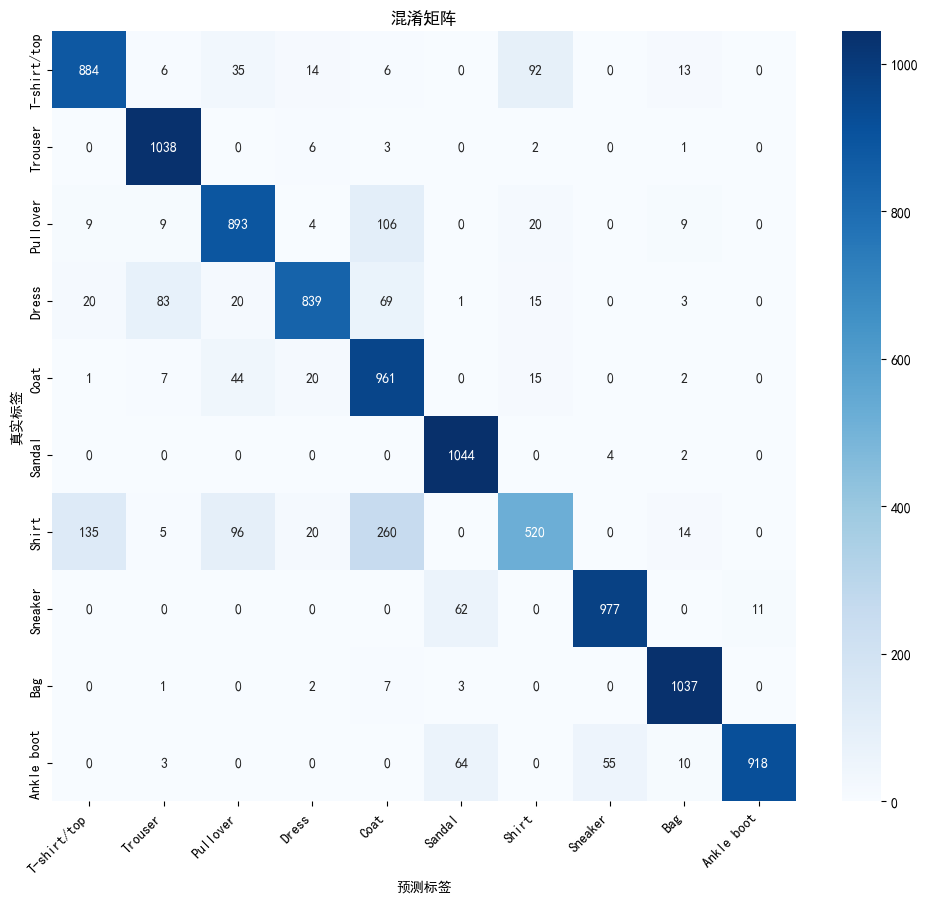

In [5]:
# 预测示例（假定已有训练并得到 history）
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
print_classification_report(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred, save_path=os.path.join(config.OUTPUT_DIR, 'confusion_matrix.png'))


## 6. 结果导出为 HTML

建议在本地运行以下命令将 Notebook 导出为 HTML（生成的 HTML 会保存在 `output/` 目录中）：

```bash
pip install jupyter nbconvert
jupyter nbconvert --to html fashion_mnist_notebook.ipynb --output output/fashion_mnist_notebook.html
```

